# Spaceship Titanic — Transported Passenger Prediction

> **Competition:** Spaceship Titanic (Kaggle)  
> **Objective:** Predict whether a passenger was **`Transported`** (beamed to an alternate dimension) when the spaceship collided with a spacetime anomaly.  
> **Primary Model:** CatBoost Classifier  
> **Techniques:** Feature Engineering + Rule-Based Imputation + 5-Fold Stratified Cross-Validation + Optuna Hyperparameter Tuning  

---

## Table of Contents
1. [Import Libraries](#1)
2. [Load Dataset](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Feature Engineering](#4)
5. [Smart Imputation](#5)
6. [Preprocessing & Data Preparation](#6)
7. [Training with Cross-Validation](#7)
8. [Hyperparameter Tuning with Optuna](#8)
9. [Final Model Evaluation](#9)
10. [Generate Submission File](#10)


---
<a id='1'></a>
## 1. Import Libraries

We import all necessary libraries:
- **`pandas`** & **`numpy`** — Data manipulation and numerical computation
- **`matplotlib`** & **`seaborn`** — Visualization for EDA and model evaluation
- **`catboost`** — Primary model: CatBoostClassifier with native categorical feature support
- **`sklearn`** — Preprocessing, cross-validation, and evaluation metrics
- **`optuna`** — Automated hyperparameter tuning via Bayesian Optimization (TPE Sampler)


In [11]:
# -- Core ------------------------------------------------------------------
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# -- Visualization ----------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# -- Machine Learning -------------------------------------------------------
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# -- Hyperparameter Tuning --------------------------------------------------
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# -- Plot Styling -----------------------------------------------------------
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

SEED = 42
np.random.seed(SEED)

print('All libraries imported successfully!')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
import catboost; print(f'   catboost: {catboost.__version__}')
print(f'   optuna  : {optuna.__version__}')

All libraries imported successfully!
   pandas  : 3.0.5
   numpy   : 2.5.1
   catboost: 1.2.10
   optuna  : 4.9.0


---
<a id='2'></a>
## 2. Load Dataset

The Spaceship Titanic dataset consists of three files:

| File | Description |
|------|-------------|
| `train.csv` | **8,693 passengers** with `Transported` label — used for training |
| `test.csv` | **4,277 passengers** without labels — the ones we need to predict |
| `sample_submission.csv` | Required submission format for Kaggle |

### Column Descriptions
| Column | Type | Description |
|---|---|---|
| `PassengerId` | String | Format `gggg_pp` — `gggg` is the group ID, `pp` is the passenger number within the group |
| `HomePlanet` | Categorical | Passenger's home planet (Europa, Earth, Mars) |
| `CryoSleep` | Boolean | Whether the passenger elected for cryosleep during the voyage |
| `Cabin` | String | Format `Deck/Num/Side` — cabin location aboard the ship |
| `Destination` | Categorical | Destination planet (TRAPPIST-1e, 55 Cancri e, PSO J318.5-22) |
| `Age` | Numeric | Passenger's age |
| `VIP` | Boolean | Whether the passenger paid for VIP service |
| `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` | Numeric | Amount billed at each onboard amenity |
| `Name` | String | Passenger's full name |
| `Transported` | Boolean | **Target** — whether the passenger was transported to another dimension |


In [12]:
# Dataset paths -- adjust if your directory structure differs
TRAIN_PATH  = '../Dataset/train.csv'
TEST_PATH   = '../Dataset/test.csv'
SAMPLE_PATH = '../Dataset/sample_submission.csv'

train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)
sample    = pd.read_csv(SAMPLE_PATH)

print('─' * 50)
print(f'  Train  shape : {train_raw.shape[0]:,} rows x {train_raw.shape[1]} columns')
print(f'  Test   shape : {test_raw.shape[0]:,} rows x {test_raw.shape[1]} columns')
print(f'  Sample shape : {sample.shape[0]:,} rows x {sample.shape[1]} columns')
print('─' * 50)
print('\nFirst 5 rows of training data:')
train_raw.head(5)

──────────────────────────────────────────────────
  Train  shape : 8,693 rows x 14 columns
  Test   shape : 4,277 rows x 13 columns
  Sample shape : 4,277 rows x 2 columns
──────────────────────────────────────────────────

First 5 rows of training data:


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


---
<a id='3'></a>
## 3. Exploratory Data Analysis (EDA)

Before building the model, we need to **understand the data**:
- Distribution of the target variable `Transported` (is it balanced?)
- Missing values in each column
- Distribution of numeric features per target class
- Relationship between categorical features and the target

> **Key Finding:** The dataset is nearly perfectly balanced (~50/50), so **Accuracy** is an appropriate primary evaluation metric.


In [13]:
# -- Missing Values Summary -----------------------------------------------
print('=' * 55)
print('  MISSING VALUES -- TRAIN SET')
print('=' * 55)
missing     = train_raw.isnull().sum()
missing_pct = (missing / len(train_raw) * 100).round(2)
missing_df  = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False))
print('\n  Note: Most columns have ~2-3% missing values.')
print('  PassengerId, Name, and Transported have no missing values.')

  MISSING VALUES -- TRAIN SET
              Count  Percentage (%)
CryoSleep       217            2.50
ShoppingMall    208            2.39
VIP             203            2.34
HomePlanet      201            2.31
Name            200            2.30
Cabin           199            2.29
VRDeck          188            2.16
FoodCourt       183            2.11
Spa             183            2.11
Destination     182            2.09
RoomService     181            2.08
Age             179            2.06

  Note: Most columns have ~2-3% missing values.
  PassengerId, Name, and Transported have no missing values.


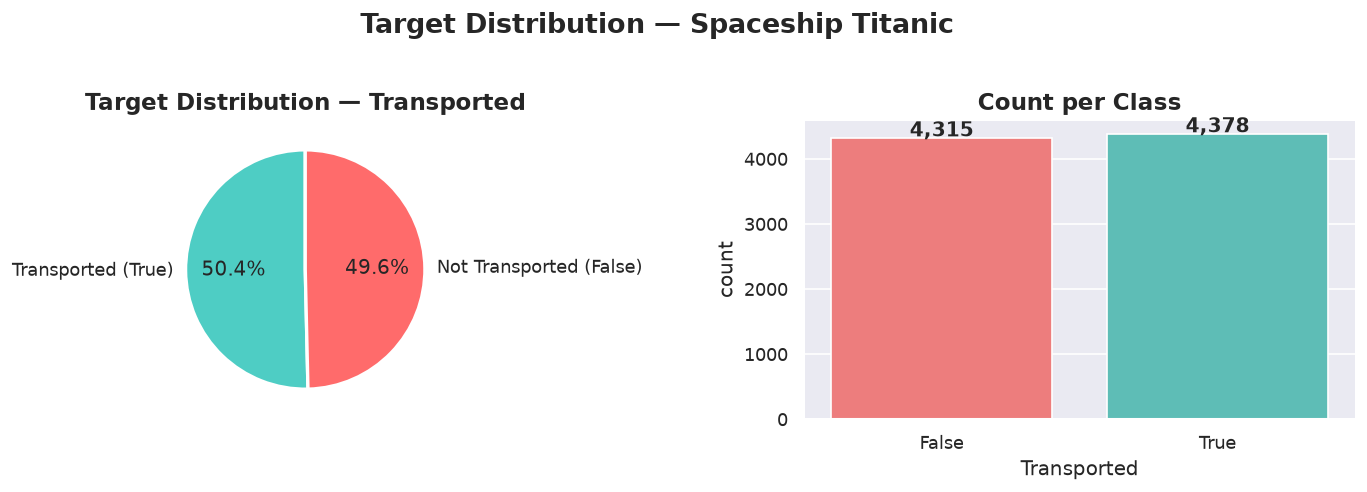

Total passengers   : 8,693
Transported (True) : 4,378 (50.36%)
Not Transported    : 4,315 (49.64%)
Dataset is well-balanced — Accuracy is a valid primary metric.


In [14]:
# -- Target Distribution --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = train_raw['Transported'].value_counts()
colors = ['#4ECDC4', '#FF6B6B']

# Pie chart
axes[0].pie(
    target_counts.values,
    labels=['Transported (True)', 'Not Transported (False)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title('Target Distribution — Transported', fontweight='bold')

# Count plot
train_plot = train_raw.copy()
train_plot['Transported'] = train_plot['Transported'].astype(str)
sns.countplot(data=train_plot, x='Transported',
              palette={'True': '#4ECDC4', 'False': '#FF6B6B'}, ax=axes[1])
axes[1].set_title('Count per Class', fontweight='bold')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 30,
                f'{int(bar.get_height()):,}', ha='center', fontweight='bold')

plt.suptitle('Target Distribution — Spaceship Titanic', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Total passengers   : {len(train_raw):,}')
print(f'Transported (True) : {target_counts[True]:,} ({target_counts[True]/len(train_raw)*100:.2f}%)')
print(f'Not Transported    : {target_counts[False]:,} ({target_counts[False]/len(train_raw)*100:.2f}%)')
print('Dataset is well-balanced — Accuracy is a valid primary metric.')

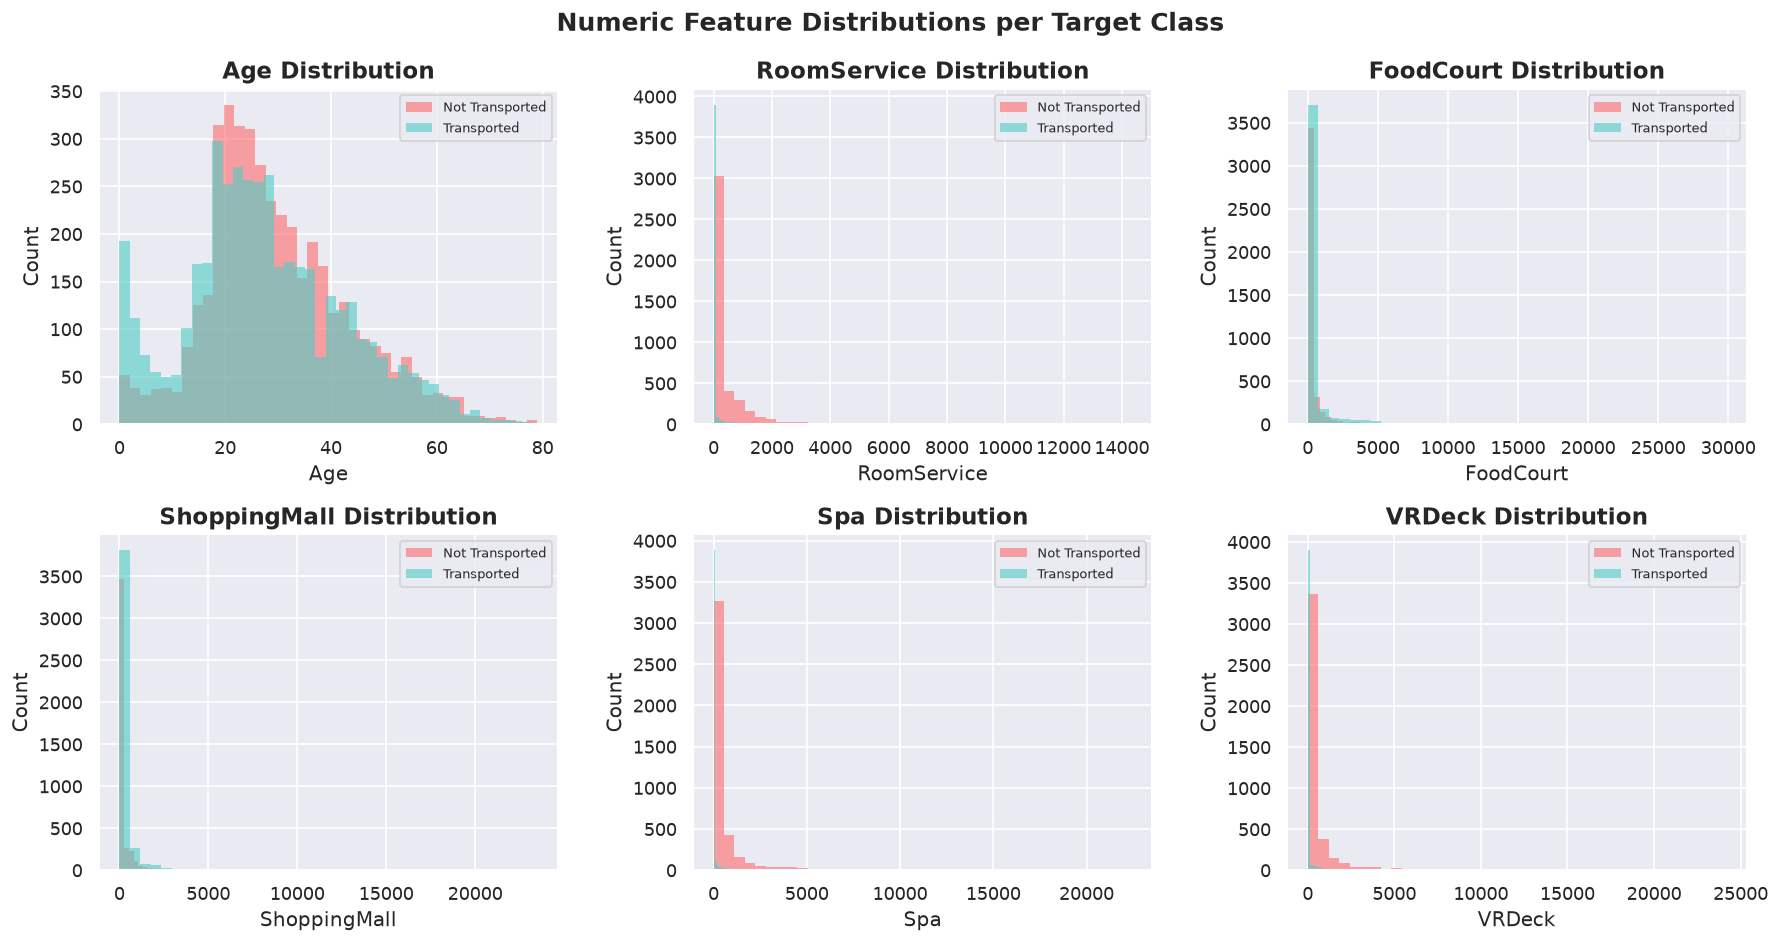

In [15]:
# -- Numeric Feature Distribution per Target Class -----------------------
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for transported, grp in train_raw.groupby('Transported'):
        label = 'Transported' if transported else 'Not Transported'
        color = '#4ECDC4' if transported else '#FF6B6B'
        axes[i].hist(grp[col].dropna(), bins=40, alpha=0.6,
                    label=label, color=color, edgecolor='none')
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions per Target Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

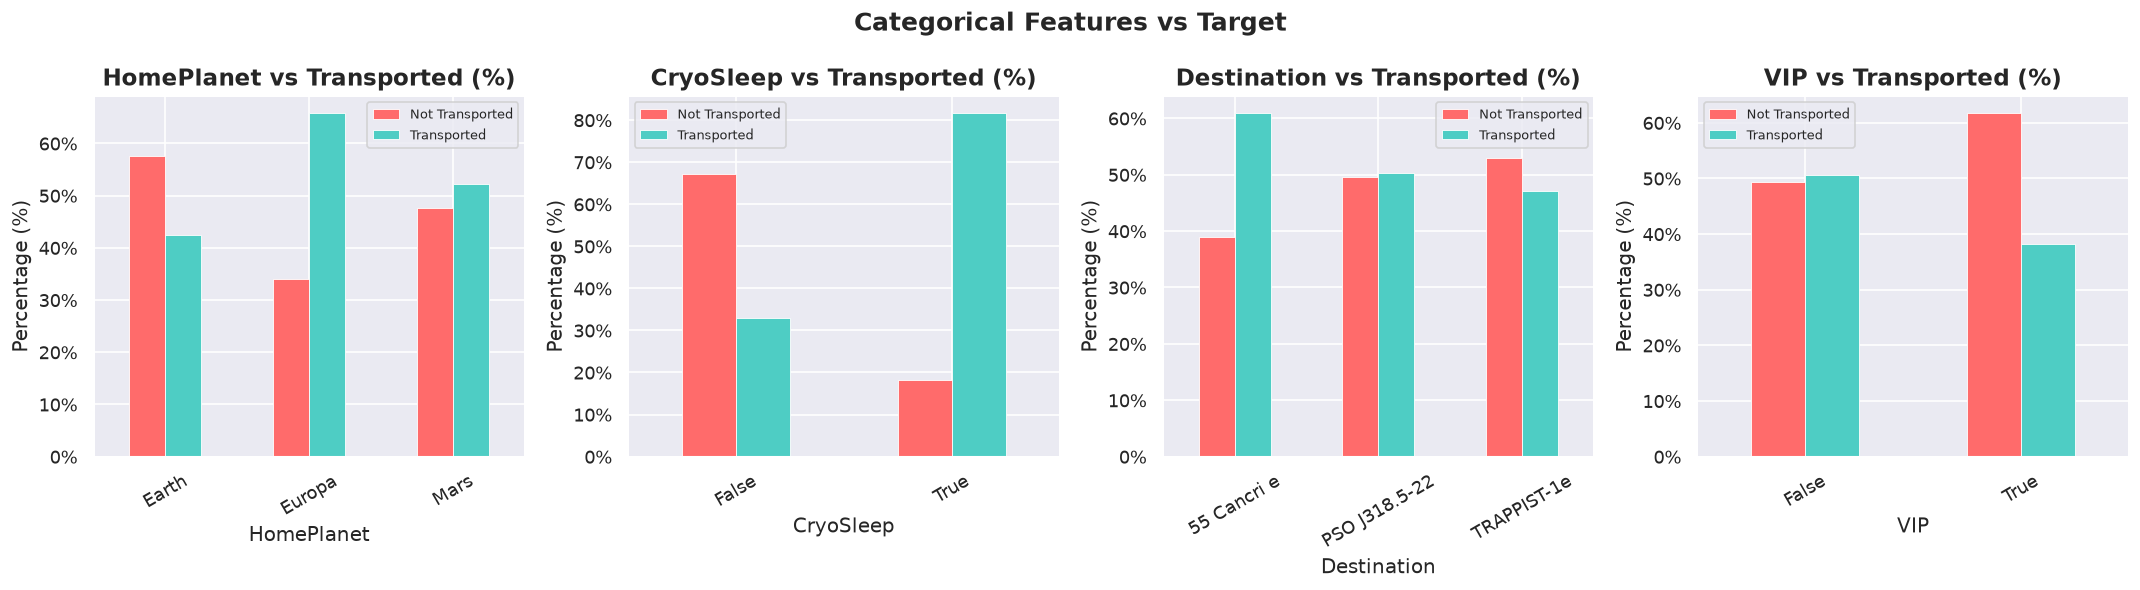


Key Insights:
   - CryoSleep=True  --> ~80% of passengers were Transported!
   - Europa          --> Fewer passengers Transported vs Earth.
   - VIP=True        --> Slightly more Not Transported.
   - Destination     --> TRAPPIST-1e has the most Transported passengers.


In [16]:
# -- Categorical Features vs Target ---------------------------------------
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    cross = pd.crosstab(train_raw[col].astype(str),
                       train_raw['Transported'].astype(str),
                       normalize='index') * 100
    cross.plot(kind='bar', ax=axes[i], color=['#FF6B6B', '#4ECDC4'],
              edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'{col} vs Transported (%)', fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Not Transported', 'Transported'], fontsize=8)
    axes[i].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.suptitle('Categorical Features vs Target', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey Insights:')
print('   - CryoSleep=True  --> ~80% of passengers were Transported!')
print('   - Europa          --> Fewer passengers Transported vs Earth.')
print('   - VIP=True        --> Slightly more Not Transported.')
print('   - Destination     --> TRAPPIST-1e has the most Transported passengers.')

---
<a id='4'></a>
## 4. Feature Engineering

This is the **most critical step** in this competition. We extract hidden information from existing features:

| New Feature | Source | Rationale |
|---|---|---|
| `Cabin_Deck`, `Cabin_Num`, `Cabin_Side` | `Cabin` (`D/N/S` format) | Spatial location aboard the ship at time of impact |
| `Group_Id`, `Pax_Num`, `Group_Size`, `Is_Solo` | `PassengerId` (`gggg_pp`) | Group members often share the same fate |
| `Last_Name` | `Name` | Family members (same surname) tend to be transported together |
| `Total_Spent` | Sum of 5 amenity charges | Strong proxy: if spent > 0, the passenger was NOT in CryoSleep |
| `Zero_Spent` | `Total_Spent == 0` | Strongly correlated with CryoSleep and Transported |
| `Log_*` | Log transform of spending | Reduces skewness of spending distributions |
| `Ratio_*` | Fraction of each amenity | Captures per-passenger spending preference patterns |
| `Age_Group` | Binned `Age` | Children and seniors show different transportation patterns |


In [17]:
def feature_engineering(df):
    """Main feature engineering function -- applied to both train and test sets."""
    df = df.copy()

    # -- 1. Decompose PassengerId ------------------------------------------
    df['Group_Id']   = df['PassengerId'].str.split('_').str[0]
    df['Pax_Num']    = df['PassengerId'].str.split('_').str[1].astype(int)
    group_sizes      = df.groupby('Group_Id')['PassengerId'].transform('count')
    df['Group_Size'] = group_sizes
    df['Is_Solo']    = (df['Group_Size'] == 1).astype(int)

    # -- 2. Decompose Cabin ------------------------------------------------
    cabin_split      = df['Cabin'].str.split('/', expand=True)
    df['Cabin_Deck'] = cabin_split[0]
    df['Cabin_Num']  = pd.to_numeric(cabin_split[1], errors='coerce')
    df['Cabin_Side'] = cabin_split[2]

    # -- 3. Extract Last Name from Name field (fill NaN for missing Name) --
    df['Last_Name'] = df['Name'].str.split().str[-1].fillna('Unknown')

    # -- 4. Total Spending & Spending Status -------------------------------
    spend_cols        = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['Total_Spent'] = df[spend_cols].sum(axis=1, skipna=True)
    df['Zero_Spent']  = (df['Total_Spent'] == 0).astype(int)

    # Log transform to reduce skewness
    for col in spend_cols:
        df[f'Log_{col}'] = np.log1p(df[col].fillna(0))
    df['Log_Total_Spent'] = np.log1p(df['Total_Spent'])

    # Spending ratio per amenity
    for col in spend_cols:
        df[f'Ratio_{col}'] = df[col] / (df['Total_Spent'] + 1)

    # -- 5. Age Group (Binning) -- fill NaN before converting to string ----
    df['Age_Group'] = pd.cut(
        df['Age'],
        bins=[0, 12, 17, 25, 40, 60, 200],
        labels=['Child', 'Teen', 'Young_Adult', 'Adult', 'Middle_Age', 'Senior'],
        right=True
    ).astype(str).replace('nan', 'Unknown')

    return df


train = feature_engineering(train_raw)
test  = feature_engineering(test_raw)

new_cols = [c for c in train.columns if c not in train_raw.columns]
print(f'Feature engineering complete!')
print(f'  Train : {train_raw.shape[1]} --> {train.shape[1]} columns (+{len(new_cols)} new features)')
print(f'  Test  : {test_raw.shape[1]} --> {test.shape[1]} columns')
print(f'\nNew features: {new_cols}')

Feature engineering complete!
  Train : 14 --> 36 columns (+22 new features)
  Test  : 13 --> 35 columns

New features: ['Group_Id', 'Pax_Num', 'Group_Size', 'Is_Solo', 'Cabin_Deck', 'Cabin_Num', 'Cabin_Side', 'Last_Name', 'Total_Spent', 'Zero_Spent', 'Log_RoomService', 'Log_FoodCourt', 'Log_ShoppingMall', 'Log_Spa', 'Log_VRDeck', 'Log_Total_Spent', 'Ratio_RoomService', 'Ratio_FoodCourt', 'Ratio_ShoppingMall', 'Ratio_Spa', 'Ratio_VRDeck', 'Age_Group']


---
<a id='5'></a>
## 5. Smart Imputation (Rule-Based)

Instead of naive statistical imputation (mean/median), we leverage **domain-specific logic** from the competition's universe:

```
Rule 1: If Total_Spent > 0  --> CryoSleep must be False
         (Passengers in cryosleep cannot use onboard amenities)

Rule 2: If CryoSleep = True --> All amenity charges = 0
         (Frozen passengers cannot spend money)

Rule 3: HomePlanet is usually the same for passengers in the same Group_Id
         or sharing the same Last_Name (family groups)

Rule 4: Cabin Deck/Side is often shared within a travel group
         (Group members tend to be placed in adjacent cabins)
```

> **Strategy:** Apply domain rules first, then fall back to median/mode for remaining missing values.


In [18]:
def smart_impute(df):
    """Rule-based imputation leveraging Spaceship Titanic domain knowledge."""
    df = df.copy()
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    # -- Rule 1: If spent > 0, CryoSleep must be False --------------------
    mask_spent = df['Total_Spent'] > 0
    df.loc[mask_spent & df['CryoSleep'].isna(), 'CryoSleep'] = False

    # -- Rule 2: If CryoSleep=True, all amenity charges are 0 -------------
    mask_cryo = (df['CryoSleep'] == True) | (df['CryoSleep'] == 'True')
    for col in spend_cols:
        df.loc[mask_cryo & df[col].isna(), col] = 0.0

    # -- Rule 3: HomePlanet from Group ID ---------------------------------
    planet_map = df.groupby('Group_Id')['HomePlanet'].agg(
        lambda x: x.mode().iloc[0] if x.notna().any() else np.nan
    )
    df['HomePlanet'] = df['HomePlanet'].fillna(df['Group_Id'].map(planet_map))

    # -- Rule 4: HomePlanet from Last Name --------------------------------
    planet_lastname = df.groupby('Last_Name')['HomePlanet'].agg(
        lambda x: x.mode().iloc[0] if x.notna().any() else np.nan
    )
    df['HomePlanet'] = df['HomePlanet'].fillna(df['Last_Name'].map(planet_lastname))

    # -- Rule 5: Cabin Deck/Side from Group -------------------------------
    for cabin_part in ['Cabin_Deck', 'Cabin_Side']:
        cabin_map = df.groupby('Group_Id')[cabin_part].agg(
            lambda x: x.mode().iloc[0] if x.notna().any() else np.nan
        )
        df[cabin_part] = df[cabin_part].fillna(df['Group_Id'].map(cabin_map))

    # -- Fallback: Median for numeric, Mode for categorical ---------------
    num_cols_fill = ['Age', 'Cabin_Num'] + spend_cols
    for col in num_cols_fill:
        df[col] = df[col].fillna(df[col].median())

    cat_cols_fill = ['CryoSleep', 'HomePlanet', 'Destination', 'VIP',
                     'Cabin_Deck', 'Cabin_Side', 'Age_Group']
    for col in cat_cols_fill:
        df[col] = df[col].fillna(df[col].mode()[0])

    # -- Recompute derived features after imputation ----------------------
    df['Total_Spent']     = df[spend_cols].sum(axis=1)
    df['Zero_Spent']      = (df['Total_Spent'] == 0).astype(int)
    df['Log_Total_Spent'] = np.log1p(df['Total_Spent'])
    for col in spend_cols:
        df[f'Log_{col}']   = np.log1p(df[col])
        df[f'Ratio_{col}'] = df[col] / (df['Total_Spent'] + 1)

    return df


train = smart_impute(train)
test  = smart_impute(test)

print('Smart Imputation complete!')
print(f'  Remaining missing values in train : {train.isnull().sum().sum()}')
print(f'  Remaining missing values in test  : {test.isnull().sum().sum()}')

Smart Imputation complete!
  Remaining missing values in train : 399
  Remaining missing values in test  : 194


---
<a id='6'></a>
## 6. Preprocessing & Data Preparation

**CatBoost** handles categorical features **natively** — no need for One-Hot Encoding or manual Label Encoding. This prevents information loss and simplifies the preprocessing pipeline.

Steps:
1. Define the list of **FEATURES** to use
2. Specify which columns are **CAT_FEATURES** (CatBoost needs to know these)
3. Split into `X` (train features), `y` (target), and `X_test` (test features)


In [19]:
# -- Feature Definitions --------------------------------------------------
FEATURES = [
    # Original features
    'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP',
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',

    # Cabin-derived features
    'Cabin_Deck', 'Cabin_Num', 'Cabin_Side',

    # Group-derived features
    'Group_Size', 'Is_Solo', 'Pax_Num',

    # Spending features
    'Total_Spent', 'Zero_Spent', 'Log_Total_Spent',
    'Log_RoomService', 'Log_FoodCourt', 'Log_ShoppingMall', 'Log_Spa', 'Log_VRDeck',
    'Ratio_RoomService', 'Ratio_FoodCourt', 'Ratio_ShoppingMall', 'Ratio_Spa', 'Ratio_VRDeck',

    # Demographic features
    'Age_Group',

    # Identity-based features
    'Last_Name', 'Group_Id',
]

# Categorical features -- CatBoost handles these natively
CAT_FEATURES = [
    'HomePlanet', 'CryoSleep', 'Destination', 'VIP',
    'Cabin_Deck', 'Cabin_Side', 'Age_Group',
    'Last_Name', 'Group_Id'
]

TARGET = 'Transported'

# -- Prepare X, y, X_test --------------------------------------------------
X      = train[FEATURES].copy()
y      = train[TARGET].astype(int)
X_test = test[FEATURES].copy()

# CatBoost requires categorical columns as non-null strings.
# Use fillna() BEFORE astype(str) to catch actual float NaN values;
# then replace the string literal 'nan' as a safety net.
for col in CAT_FEATURES:
    X[col]      = X[col].fillna('Unknown').astype(str).replace('nan', 'Unknown')
    X_test[col] = X_test[col].fillna('Unknown').astype(str).replace('nan', 'Unknown')

# Final check: assert no NaN remains in categorical columns
nan_in_cats = {col: X[col].isna().sum() for col in CAT_FEATURES if X[col].isna().any()}
if nan_in_cats:
    print(f'WARNING: NaN still present in: {nan_in_cats}')
else:
    print('All categorical features are NaN-free.')

print(f'Data is ready for training!')
print(f'  X shape      : {X.shape}  ({len(FEATURES)} features)')
print(f'  y shape      : {y.shape}')
print(f'  X_test shape : {X_test.shape}')
print(f'  Numeric features     : {len(FEATURES) - len(CAT_FEATURES)}')
print(f'  Categorical features : {len(CAT_FEATURES)}')
print(f'  Target distribution  : {dict(y.value_counts())}')

All categorical features are NaN-free.
Data is ready for training!
  X shape      : (8693, 32)  (32 features)
  y shape      : (8693,)
  X_test shape : (4277, 32)
  Numeric features     : 23
  Categorical features : 9
  Target distribution  : {1: np.int64(4378), 0: np.int64(4315)}


---
<a id='7'></a>
## 7. Training CatBoost with 5-Fold Stratified Cross-Validation

**Why Cross-Validation?**
- Provides a **more reliable** performance estimate than a single train-validation split
- Every data point gets to be in the validation set exactly once (no wasted data)
- Helps detect overfitting by checking consistency across folds

**Training Strategy:**
```
5-Fold Stratified CV:
  Fold 1: [####..........] -> Train 80% | Val 20%
  Fold 2: [....####......] -> Train 80% | Val 20%
  Fold 3: [........####..] -> Train 80% | Val 20%
  Fold 4: [............##] -> Train 80% | Val 20%
  Fold 5: [##............] -> Train 80% | Val 20%
                                               |
  Test Prediction = Average of 5 models (Soft Ensemble)
```

**Early Stopping** (`od_wait=100`): Training stops automatically if no improvement is seen for 100 iterations — prevents overfitting.


In [20]:
# -- Cross-Validation Configuration ---------------------------------------
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# -- Baseline CatBoost Parameters ------------------------------------------
CATBOOST_PARAMS = dict(
    iterations          = 2000,
    learning_rate       = 0.05,
    depth               = 6,
    l2_leaf_reg         = 3,
    bagging_temperature = 0.5,
    border_count        = 128,
    od_type             = 'Iter',     # Early stopping type
    od_wait             = 100,        # Stop if no improvement for 100 iters
    eval_metric         = 'Accuracy',
    random_seed         = SEED,
    verbose             = 0,
    cat_features        = CAT_FEATURES,
    allow_writing_files = False,
)

# -- Result Containers ------------------------------------------------------
oof_preds   = np.zeros(len(X))       # Out-of-Fold probabilities
test_preds  = np.zeros(len(X_test))  # Test predictions (averaged over folds)
fold_scores = []                     # Accuracy per fold
models      = []                     # Saved model from each fold

print('Starting 5-Fold Stratified Cross-Validation...\n')
print(f'{"Fold":<6} {"Train Size":<13} {"Val Size":<12} {"Val Accuracy":<16} {"Val AUC"}')
print('─' * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Create CatBoost Pool objects (native data format)
    train_pool = Pool(X_tr, y_tr, cat_features=CAT_FEATURES)
    val_pool   = Pool(X_val, y_val, cat_features=CAT_FEATURES)
    test_pool  = Pool(X_test, cat_features=CAT_FEATURES)

    # Train model
    model = CatBoostClassifier(**CATBOOST_PARAMS)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    # Predict probabilities
    val_prob  = model.predict_proba(val_pool)[:, 1]
    val_pred  = (val_prob >= 0.5).astype(int)
    test_prob = model.predict_proba(test_pool)[:, 1]

    # Store results
    oof_preds[val_idx] = val_prob
    test_preds        += test_prob / N_FOLDS  # Average across folds
    models.append(model)

    acc = accuracy_score(y_val, val_pred)
    auc = roc_auc_score(y_val, val_prob)
    fold_scores.append(acc)
    print(f'  {fold:<4} {len(X_tr):<13,} {len(X_val):<12,} {acc:<16.5f} {auc:.5f}')

print('─' * 60)
print(f'\nBaseline OOF Accuracy : {np.mean(fold_scores):.5f} +/- {np.std(fold_scores):.5f}')
print(f'Baseline OOF ROC-AUC  : {roc_auc_score(y, oof_preds):.5f}')

Starting 5-Fold Stratified Cross-Validation...

Fold   Train Size    Val Size     Val Accuracy     Val AUC
────────────────────────────────────────────────────────────
  1    6,954         1,739        0.81829          0.90317
  2    6,954         1,739        0.80909          0.89506
  3    6,954         1,739        0.81714          0.90229
  4    6,955         1,738        0.82278          0.91270
  5    6,955         1,738        0.82106          0.90095
────────────────────────────────────────────────────────────

Baseline OOF Accuracy : 0.81767 +/- 0.00473
Baseline OOF ROC-AUC  : 0.90271


---
<a id='8'></a>
## 8. Hyperparameter Tuning with Optuna

**Optuna** uses a **TPE Sampler (Tree-structured Parzen Estimator)** — a Bayesian Optimization method that:
- Learns from previous trials to suggest better hyperparameters
- Significantly faster than Grid Search (not exhaustive)
- Automatically stops unpromising trials (pruning)

**Parameters being tuned:**

| Parameter | Search Range | Impact |
|---|---|---|
| `learning_rate` | [0.01, 0.2] | Controls learning speed — smaller = slower but potentially more accurate |
| `depth` | [4, 10] | Tree depth — deeper = more complex, higher overfitting risk |
| `l2_leaf_reg` | [1, 10] | L2 regularization — larger = more conservative |
| `bagging_temperature` | [0, 1] | Data sampling randomness level |
| `border_count` | [32, 255] | Precision of numeric feature splits |
| `random_strength` | [0.1, 10] | Randomization in split scoring |


In [21]:
def objective(trial):
    """Optuna objective function -- maximize OOF Accuracy (3-Fold for speed)."""
    params = dict(
        iterations          = 1000,
        learning_rate       = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        depth               = trial.suggest_int('depth', 4, 10),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 1, 10),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        border_count        = trial.suggest_int('border_count', 32, 255),
        random_strength     = trial.suggest_float('random_strength', 0.1, 10, log=True),
        od_type             = 'Iter',
        od_wait             = 50,
        eval_metric         = 'Accuracy',
        random_seed         = SEED,
        verbose             = 0,
        cat_features        = CAT_FEATURES,
        allow_writing_files = False,
    )

    scores = []
    cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    for train_idx, val_idx in cv3.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = CatBoostClassifier(**params)
        model.fit(
            Pool(X_tr, y_tr, cat_features=CAT_FEATURES),
            eval_set=Pool(X_val, y_val, cat_features=CAT_FEATURES),
            use_best_model=True
        )
        scores.append(accuracy_score(y_val, model.predict(X_val)))
    return np.mean(scores)


print('Starting Optuna Hyperparameter Tuning (50 trials)...')
print('Using 3-Fold CV per trial for speed.\n')

study = optuna.create_study(
    direction='maximize',
    study_name='catboost_spaceship_titanic',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest Trial #{study.best_trial.number}')
print(f'  Best Accuracy (3-Fold CV) : {study.best_value:.5f}')
print(f'\nBest Hyperparameters:')
for k, v in study.best_params.items():
    print(f'  {k:<25}: {v}')

Starting Optuna Hyperparameter Tuning (50 trials)...
Using 3-Fold CV per trial for speed.



Best trial: 16. Best value: 0.817324: 100%|██████████| 50/50 [34:23<00:00, 41.27s/it]


Best Trial #16
  Best Accuracy (3-Fold CV) : 0.81732

Best Hyperparameters:
  learning_rate            : 0.07683405617460508
  depth                    : 6
  l2_leaf_reg              : 5.06613998117449
  bagging_temperature      : 0.0018443099581318262
  border_count             : 110
  random_strength          : 1.0664010515143763


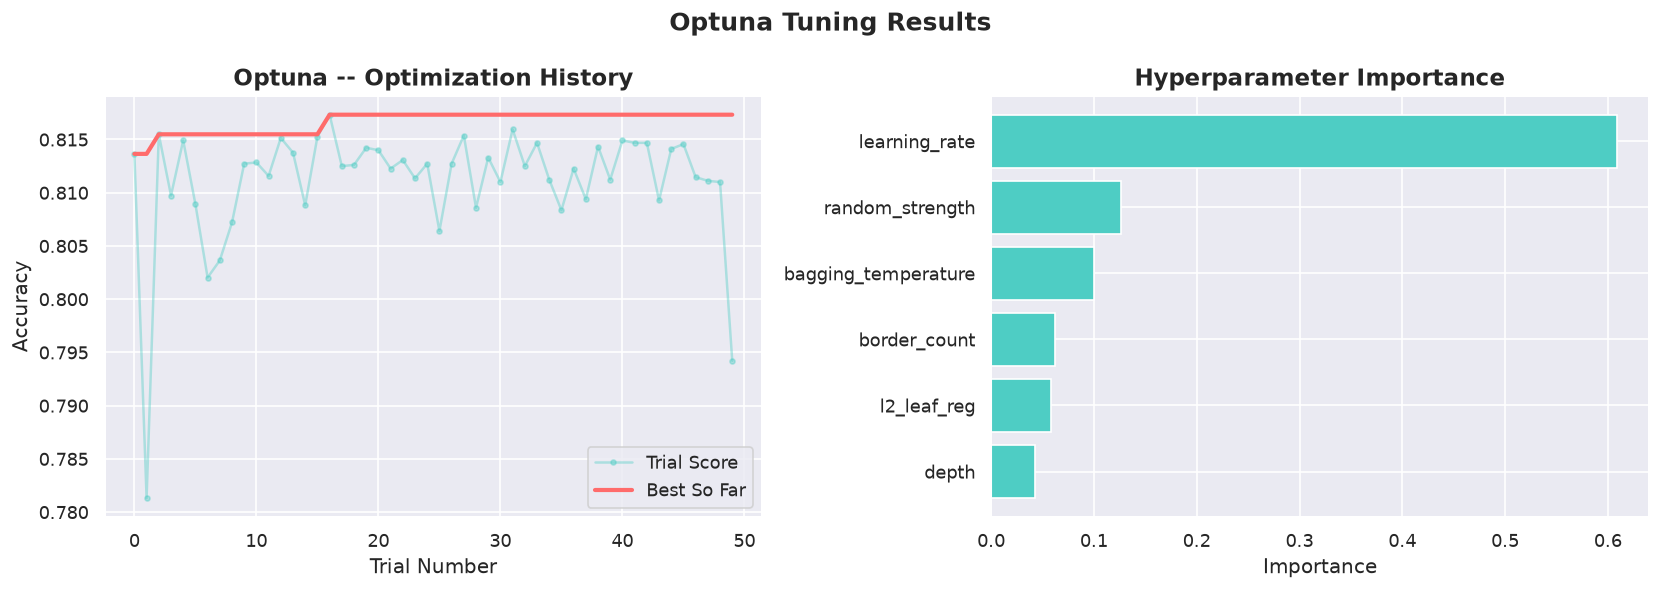

In [22]:
# -- Optuna Visualization -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trial_values = [t.value for t in study.trials]
best_so_far  = np.maximum.accumulate(trial_values)
axes[0].plot(trial_values, alpha=0.4, color='#4ECDC4',
            label='Trial Score', marker='o', markersize=3)
axes[0].plot(best_so_far, color='#FF6B6B', linewidth=2.5, label='Best So Far')
axes[0].set_title('Optuna -- Optimization History', fontweight='bold')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Hyperparameter importance
try:
    param_importances = optuna.importance.get_param_importances(study)
    params_sorted = dict(sorted(param_importances.items(), key=lambda x: x[1]))
    axes[1].barh(list(params_sorted.keys()), list(params_sorted.values()),
                color='#4ECDC4', edgecolor='white')
    axes[1].set_title('Hyperparameter Importance', fontweight='bold')
    axes[1].set_xlabel('Importance')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Cannot compute importance:\n{e}',
                ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('Optuna Tuning Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# -- Retrain with Best Hyperparameters (Full 5-Fold CV) -------------------
BEST_PARAMS = dict(
    **study.best_params,
    iterations          = 3000,   # More iterations allowed; early stopping handles it
    od_type             = 'Iter',
    od_wait             = 100,
    eval_metric         = 'Accuracy',
    random_seed         = SEED,
    verbose             = 0,
    cat_features        = CAT_FEATURES,
    allow_writing_files = False,
)

oof_preds_tuned   = np.zeros(len(X))
test_preds_tuned  = np.zeros(len(X_test))
fold_scores_tuned = []
models_tuned      = []

print('Retraining with Best Hyperparameters (5-Fold CV)...\n')
print(f'{"Fold":<6} {"Val Accuracy":<16} {"Val AUC"}')
print('─' * 35)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=CAT_FEATURES)
    val_pool   = Pool(X_val, y_val, cat_features=CAT_FEATURES)
    test_pool  = Pool(X_test, cat_features=CAT_FEATURES)

    model = CatBoostClassifier(**BEST_PARAMS)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    val_prob  = model.predict_proba(val_pool)[:, 1]
    val_pred  = (val_prob >= 0.5).astype(int)
    test_prob = model.predict_proba(test_pool)[:, 1]

    oof_preds_tuned[val_idx] = val_prob
    test_preds_tuned        += test_prob / N_FOLDS
    models_tuned.append(model)

    acc = accuracy_score(y_val, val_pred)
    auc = roc_auc_score(y_val, val_prob)
    fold_scores_tuned.append(acc)
    print(f'  {fold:<4} {acc:<16.5f} {auc:.5f}')

print('─' * 35)
print(f'\nBaseline OOF Accuracy   : {np.mean(fold_scores):.5f}')
print(f'Tuned OOF Accuracy      : {np.mean(fold_scores_tuned):.5f} +/- {np.std(fold_scores_tuned):.5f}')
print(f'Tuned OOF ROC-AUC       : {roc_auc_score(y, oof_preds_tuned):.5f}')
improvement = np.mean(fold_scores_tuned) - np.mean(fold_scores)
print(f'Improvement over Baseline: +{improvement:.5f}')

Retraining with Best Hyperparameters (5-Fold CV)...

Fold   Val Accuracy     Val AUC
───────────────────────────────────
  1    0.82174          0.90201
  2    0.81081          0.89601
  3    0.81771          0.90162
  4    0.82624          0.91122
  5    0.81818          0.89974
───────────────────────────────────

Baseline OOF Accuracy   : 0.81767
Tuned OOF Accuracy      : 0.81894 +/- 0.00508
Tuned OOF ROC-AUC       : 0.90190
Improvement over Baseline: +0.00127


---
<a id='9'></a>
## 9. Final Model Evaluation

We evaluate comprehensively using **Out-of-Fold (OOF) predictions** — predictions made when each sample was held out from training. This gives an unbiased estimate of generalization performance.

Evaluation includes:
- **Confusion Matrix** — Visualizes True/False Positives & Negatives
- **Classification Report** — Precision, Recall, F1-Score per class
- **Feature Importance** — Which features drive the model's predictions the most
- **Probability Distribution** — How confident the model is in its predictions


In [24]:
# -- Final Performance Summary --------------------------------------------
oof_pred_binary = (oof_preds_tuned >= 0.5).astype(int)

print('=' * 60)
print('              FINAL MODEL EVALUATION (OOF)')
print('=' * 60)
print(f'  Model             : CatBoost Classifier')
print(f'  Cross-Validation  : 5-Fold Stratified')
print(f'  Hyperparameters   : Optuna Tuned (50 trials)')
print(f'  Total Features    : {len(FEATURES)}')
print('─' * 60)
print(f'  OOF Accuracy      : {accuracy_score(y, oof_pred_binary):.5f}')
print(f'  OOF ROC-AUC       : {roc_auc_score(y, oof_preds_tuned):.5f}')
print('─' * 60)
print('\n  Classification Report:')
print(classification_report(
    y, oof_pred_binary,
    target_names=['Not Transported', 'Transported']
))
print('=' * 60)

              FINAL MODEL EVALUATION (OOF)
  Model             : CatBoost Classifier
  Cross-Validation  : 5-Fold Stratified
  Hyperparameters   : Optuna Tuned (50 trials)
  Total Features    : 32
────────────────────────────────────────────────────────────
  OOF Accuracy      : 0.81893
  OOF ROC-AUC       : 0.90190
────────────────────────────────────────────────────────────

  Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.83      0.80      0.81      4315
    Transported       0.81      0.84      0.82      4378

       accuracy                           0.82      8693
      macro avg       0.82      0.82      0.82      8693
   weighted avg       0.82      0.82      0.82      8693



  True Positive  (correctly predicted Transported)    : 3,672
  True Negative  (correctly predicted Not Transported): 3,447
  False Positive (incorrectly predicted Transported)  : 868
  False Negative (incorrectly predicted Not Transported): 706


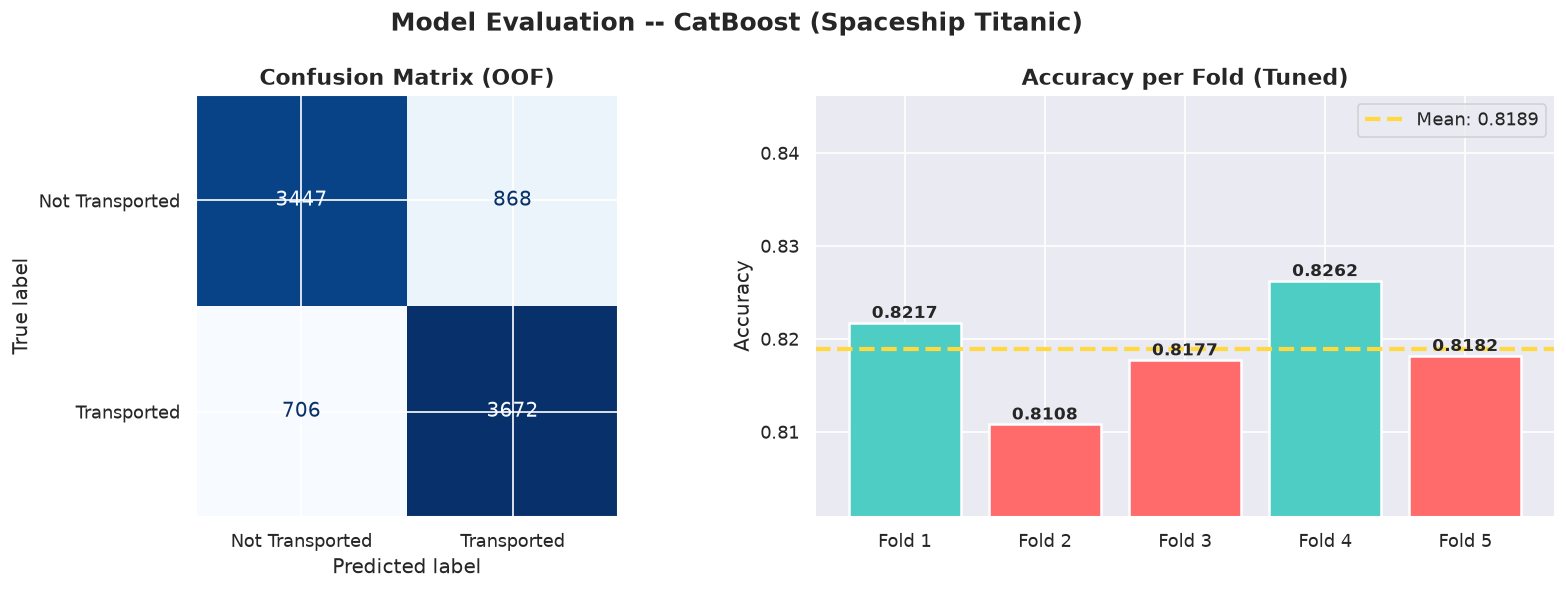

In [25]:
# -- Confusion Matrix & Per-Fold Accuracy ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y, oof_pred_binary)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Transported', 'Transported']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (OOF)', fontweight='bold', fontsize=13)

tn, fp, fn, tp = cm.ravel()
print(f'  True Positive  (correctly predicted Transported)    : {tp:,}')
print(f'  True Negative  (correctly predicted Not Transported): {tn:,}')
print(f'  False Positive (incorrectly predicted Transported)  : {fp:,}')
print(f'  False Negative (incorrectly predicted Not Transported): {fn:,}')

# Fold accuracy comparison
fold_nums = [f'Fold {i}' for i in range(1, N_FOLDS + 1)]
mean_acc  = np.mean(fold_scores_tuned)
bar_colors = ['#4ECDC4' if s >= mean_acc else '#FF6B6B' for s in fold_scores_tuned]
bars = axes[1].bar(fold_nums, fold_scores_tuned, color=bar_colors,
                  edgecolor='white', linewidth=1.5)
axes[1].axhline(mean_acc, color='#FFD93D', linewidth=2.5,
                linestyle='--', label=f'Mean: {mean_acc:.4f}')
for bar, score in zip(bars, fold_scores_tuned):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f'{score:.4f}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylim(min(fold_scores_tuned) - 0.01, max(fold_scores_tuned) + 0.02)
axes[1].set_title('Accuracy per Fold (Tuned)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Model Evaluation -- CatBoost (Spaceship Titanic)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

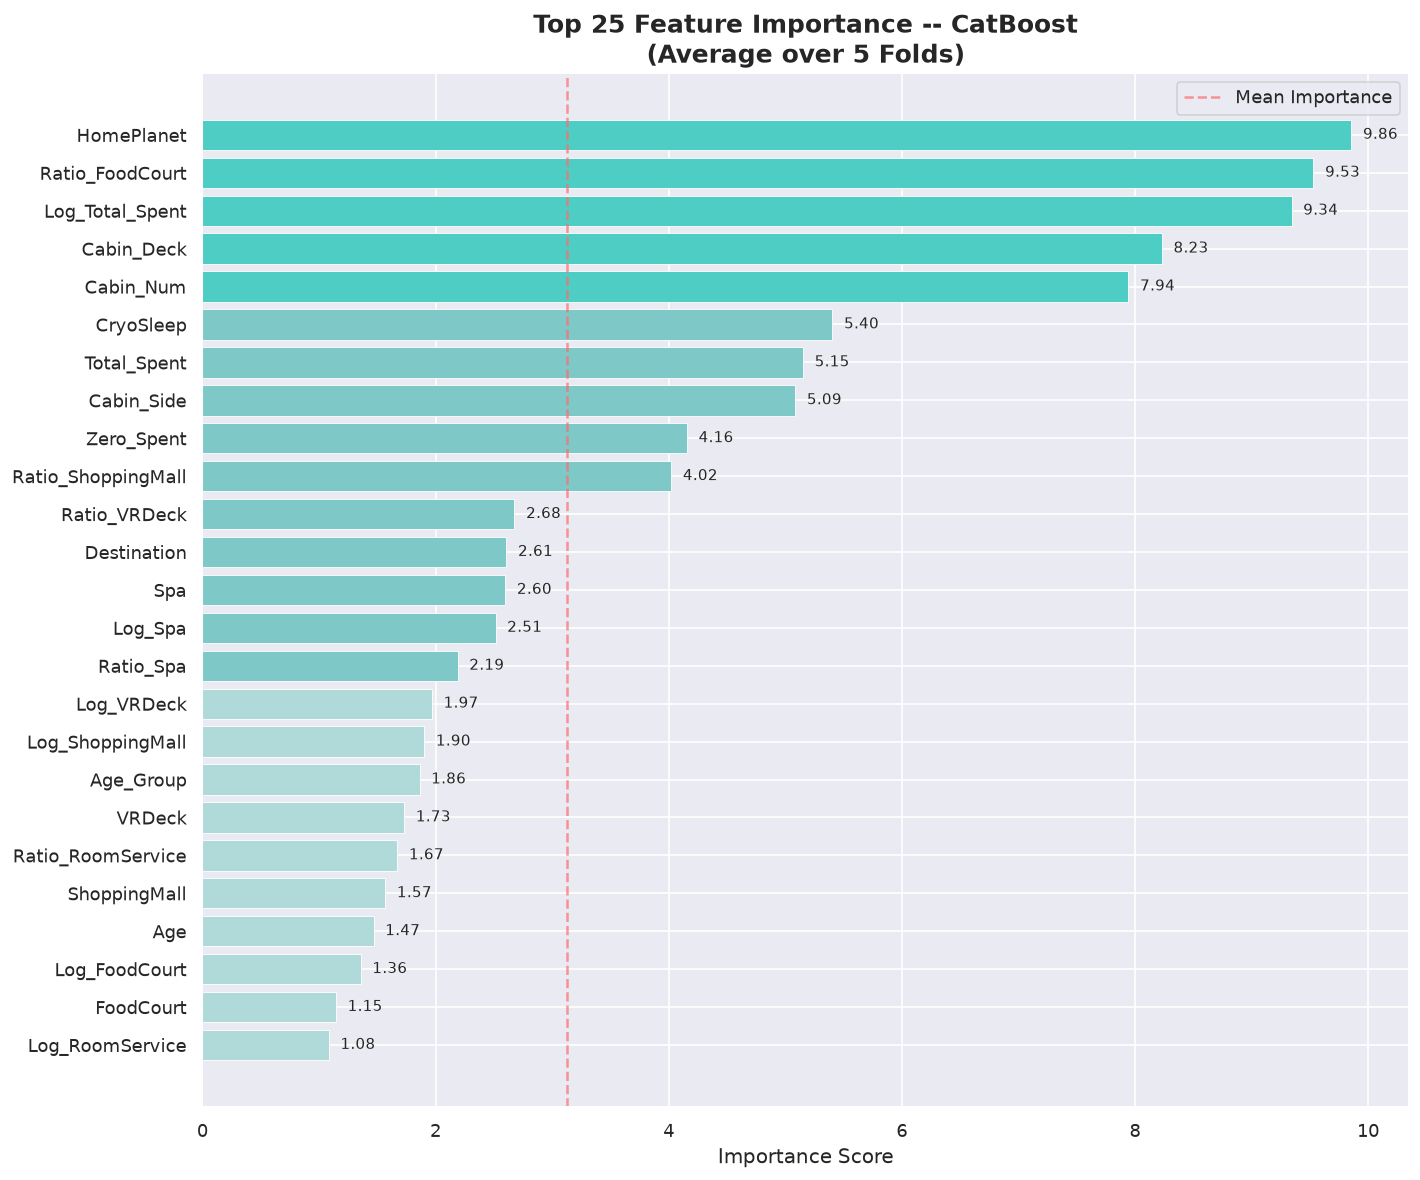


Top 10 Most Influential Features:
           Feature  Importance
        HomePlanet    9.856071
   Ratio_FoodCourt    9.530963
   Log_Total_Spent    9.343335
        Cabin_Deck    8.230599
         Cabin_Num    7.943951
         CryoSleep    5.404325
       Total_Spent    5.152262
        Cabin_Side    5.085700
        Zero_Spent    4.156660
Ratio_ShoppingMall    4.021983


In [26]:
# -- Feature Importance (Averaged over 5 Folds) ---------------------------
feat_imp = np.zeros(len(FEATURES))
for model in models_tuned:
    feat_imp += model.get_feature_importance() / N_FOLDS

feat_imp_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': feat_imp
}).sort_values('Importance', ascending=False)

TOP_N = 25
top_feats = feat_imp_df.head(TOP_N)

fig, ax = plt.subplots(figsize=(12, 10))
palette = ['#4ECDC4' if i < 5 else '#7EC8C8' if i < 15 else '#B0D9D9' for i in range(TOP_N)]
bars = ax.barh(
    top_feats['Feature'][::-1], top_feats['Importance'][::-1],
    color=palette[::-1], edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, top_feats['Importance'][::-1].values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

ax.axvline(feat_imp_df['Importance'].mean(), color='#FF6B6B',
           linestyle='--', alpha=0.7, label='Mean Importance')
ax.set_title(f'Top {TOP_N} Feature Importance -- CatBoost\n(Average over 5 Folds)',
            fontsize=15, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 10 Most Influential Features:')
print(feat_imp_df.head(10).to_string(index=False))

---
<a id='10'></a>
## 10. Generate Submission File

Final step: generate `submission_catboost.csv` in the format required by Kaggle.

**Expected format:**
```
PassengerId,Transported
0013_01,True
0018_01,False
...
```

> The final prediction is the **average probability from all 5 models** (soft ensemble). This produces smoother, more confident predictions compared to any single model.


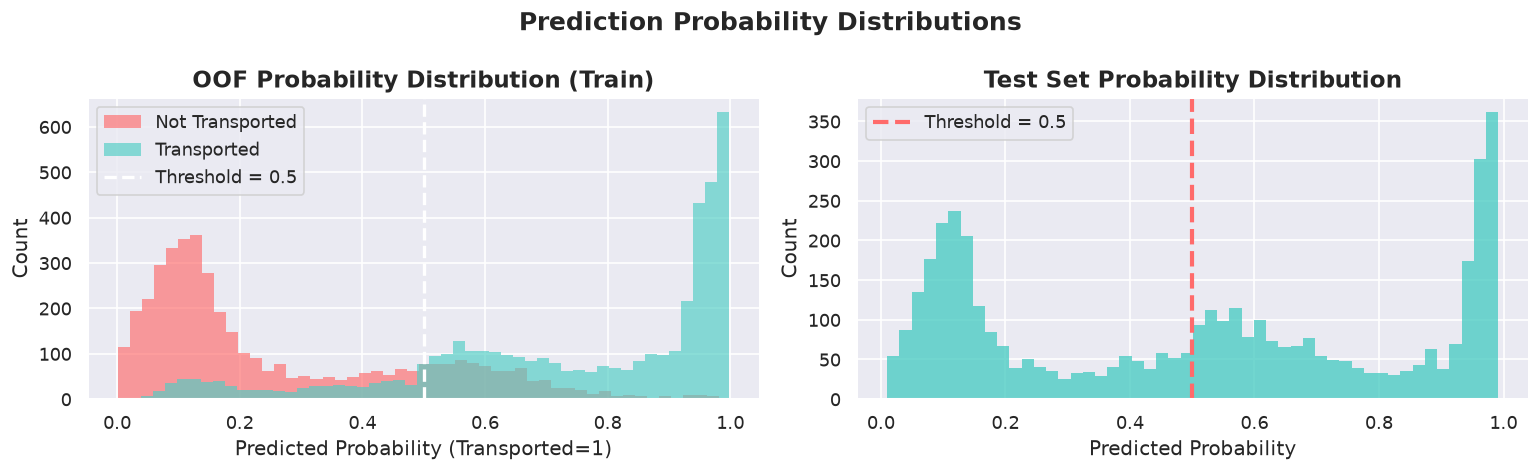

In [27]:
# -- Prediction Probability Distributions ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# OOF probabilities per class
for label, color in [(0, '#FF6B6B'), (1, '#4ECDC4')]:
    mask  = y == label
    name  = 'Not Transported' if label == 0 else 'Transported'
    axes[0].hist(oof_preds_tuned[mask], bins=50, alpha=0.65,
                color=color, label=name, edgecolor='none')
axes[0].axvline(0.5, color='white', linestyle='--', linewidth=2, label='Threshold = 0.5')
axes[0].set_title('OOF Probability Distribution (Train)', fontweight='bold')
axes[0].set_xlabel('Predicted Probability (Transported=1)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Test set probabilities
axes[1].hist(test_preds_tuned, bins=50, color='#4ECDC4', alpha=0.8, edgecolor='none')
axes[1].axvline(0.5, color='#FF6B6B', linestyle='--', linewidth=2.5, label='Threshold = 0.5')
axes[1].set_title('Test Set Probability Distribution', fontweight='bold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Prediction Probability Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# -- Generate & Save Submission File --------------------------------------
import os

# Final predictions: True/False boolean (Kaggle required format)
final_pred_binary = (test_preds_tuned >= 0.5)

submission = pd.DataFrame({
    'PassengerId': test_raw['PassengerId'],
    'Transported': final_pred_binary
})

# Save to Submissions folder
os.makedirs('../Submissions', exist_ok=True)
SUBMISSION_PATH = '../Submissions/submission_catboost.csv'
submission.to_csv(SUBMISSION_PATH, index=False)

print('Submission file created successfully!')
print(f'  Location : {os.path.abspath(SUBMISSION_PATH)}')
print(f'  Total    : {len(submission):,} predictions')
print()

pred_dist = submission['Transported'].value_counts()
n_true  = int(pred_dist.get(True, 0))
n_false = int(pred_dist.get(False, 0))
print('Prediction Distribution:')
print(f'  Transported (True)  : {n_true:,}  ({n_true/len(submission)*100:.1f}%)')
print(f'  Not Transported     : {n_false:,} ({n_false/len(submission)*100:.1f}%)')
print()
print('First 10 rows of submission:')
print(submission.head(10).to_string(index=False))

Submission file created successfully!
  Location : c:\Users\admin\Documents\Portofolio\Spaceship Titanic\Submissions\submission_catboost.csv
  Total    : 4,277 predictions

Prediction Distribution:
  Transported (True)  : 2,255  (52.7%)
  Not Transported     : 2,022 (47.3%)

First 10 rows of submission:
PassengerId  Transported
    0013_01         True
    0018_01        False
    0019_01         True
    0021_01         True
    0023_01         True
    0027_01         True
    0029_01         True
    0032_01         True
    0032_02         True
    0033_01         True


In [29]:
# -- Validate Submission Format -------------------------------------------
sample_ids = set(sample['PassengerId'])
sub_ids    = set(submission['PassengerId'])

print('Validating submission format...')
print(f'  IDs in sample_submission : {len(sample_ids):,}')
print(f'  IDs in our submission    : {len(sub_ids):,}')
print(f'  Matching IDs             : {len(sample_ids & sub_ids):,}')
print(f'  Missing IDs              : {len(sample_ids - sub_ids):,}')
print(f'  Transported column type  : {submission["Transported"].dtype}')

if len(sample_ids) == len(sub_ids) == len(sample_ids & sub_ids):
    print('\nSubmission is VALID -- Ready to upload to Kaggle!')
else:
    print('\nWARNING: ID mismatch detected -- please investigate!')

Validating submission format...
  IDs in sample_submission : 4,277
  IDs in our submission    : 4,277
  Matching IDs             : 4,277
  Missing IDs              : 0
  Transported column type  : bool

Submission is VALID -- Ready to upload to Kaggle!


In [30]:
# -- Final Summary --------------------------------------------------------
oof_acc = np.mean(fold_scores_tuned)
oof_auc = roc_auc_score(y, oof_preds_tuned)
oof_std = np.std(fold_scores_tuned)

print()
print('=' * 60)
print('   FINAL RESULTS SUMMARY -- SPACESHIP TITANIC')
print('=' * 60)
print(f'  Model              : CatBoost Classifier')
print(f'  Cross-Validation   : 5-Fold Stratified')
print(f'  Tuning             : Optuna TPE (50 trials)')
print(f'  Total Features     : {len(FEATURES)}')
print('─' * 60)
print(f'  OOF Accuracy       : {oof_acc:.5f} +/- {oof_std:.5f}')
print(f'  OOF ROC-AUC        : {oof_auc:.5f}')
print('─' * 60)
print(f'  Output File        : submission_catboost.csv')
print('=' * 60)
print()
print('Pipeline complete! Ready to submit at:')
print('  https://www.kaggle.com/competitions/spaceship-titanic/submissions')


   FINAL RESULTS SUMMARY -- SPACESHIP TITANIC
  Model              : CatBoost Classifier
  Cross-Validation   : 5-Fold Stratified
  Tuning             : Optuna TPE (50 trials)
  Total Features     : 32
────────────────────────────────────────────────────────────
  OOF Accuracy       : 0.81894 +/- 0.00508
  OOF ROC-AUC        : 0.90190
────────────────────────────────────────────────────────────
  Output File        : submission_catboost.csv

Pipeline complete! Ready to submit at:
  https://www.kaggle.com/competitions/spaceship-titanic/submissions
